# Restaurant Marketing Prioritisation Pipeline

**Objective:** Generate a prioritised list of restaurants to market, based on both current performance and emerging growth trends and GA4 demand-side signals..

**Inputs:**


**Output:** `priority_list_ga4.csv`

---
## how ga4 data is integrated in
- booking and marketing data is assumed as the base truth
   - booking data provides restaurant specific revenue data = converted demand
   - marketing data assumed as the main campaigns that hh wants to observe in detail; this data used to understand restaurant responsiveness to campaign using revenue as a metric
- ga data provides *unconverted demand*/ *quantified untapped potentials*
   - supplement restaurant information using user interactions with restaurant; user interaction funnel = view -> add to cart -> purchase
   - supplement marketing data by understanding restaurant responsiveness to campaign using any interaction (views, add to cart) as a metric
   - supplement marketing data by using gmv per view; understand potential $$ impact by increasing restaurant views

## Logic Overview
1. **Segment Stability Filter**
2. **Organic Demand Score**
   - `growth_component` — actual booking/revenue growth momentum
   - `booking_demand` — booking volume, revenue efficiency, consistency
   - `ga4_demand` — pre-booking funnel signals (listing pull, funnel depth)
3. **Campaign Responsiveness Score**
   - `internal_mkt_campaign_responsiveness` — lift + ROI from internal campaign data
   - `ga_campaign_responsiveness` — avg gmv per view from gmv_view
4. **Risk Identification & Weight Adjustment**
   - Risk 1 (thin GA demand data) → shrinks ga4 demand weight
   - Risk 2 (inverse relationship between booking & GA demand data) → shrinks ga4 demand weight
   - Risk 3 (thin GA campaign data) → shrinks ga4 campaign weight
   - Risk 4 (low GMV per view) → shrinks ga4 campaign weight
5. **Final Ranked Score**
---
### calculations
##### [first filter] **Segment Stability Filter** 
- narrows the full restaurant universe to only those consistently in a growth segment over the last N months (~251 restaurants). All others are deprioritised.

##### Base Formula
```
[with marketing history]
priority_score = growth_component    × 0.30
               + booking_demand      × 0.30
               + ga4_demand          × 0.20
               + campaign_responsiveness × 0.20

[no marketing history]
priority_score = growth_component × 0.40
               + booking_demand   × 0.40
               + ga4_demand       × 0.15
               + campaign_responsiveness x 0.05
```

##### Sub Scores — Demand
```
growth_component = score_growth_norm × 0.60 + delta_growth_norm × 0.40

booking_demand   = booking_volume_norm       × 0.40
                 + revenue_per_booking_norm  × 0.30
                 + booking_consistency_norm  × 0.30

ga4_demand       = listing_pull_norm × 0.50 + funnel_depth_norm × 0.50
  listing_pull   = avg(itemsViewed) across all months            [source: campaign_impact]
  funnel_depth   = view_to_cart_rate × 0.40 + cart_to_purchase_rate × 0.60
    view_to_cart_rate    = itemsAddedToCart / itemsViewed
    cart_to_purchase_rate = itemsPurchased  / itemsAddedToCart
```

##### Sub Scores — Campaign Responsiveness
```
campaign_responsiveness = internal_mkt_campaign_responsiveness × 0.60
                    + ga_campaign_responsiveness            × 0.40

  internal_mkt_campaign_responsiveness = lift_norm × 0.60 + roi_norm × 0.40

  ga_campaign_responsiveness = norm(avg_gmv_per_view)
  Note: every month has ≥1 active campaign so no organic baseline exists;
        avg_gmv_per_view is used as a cross-sectional signal instead of a lift.
```
_for restaurants without marketing data, avg gmv per view is used only_

##### **Dynamically reduce weightage of the scores based on risks**
- **Risk 1: <3 consecutive months of GA demand data**  
  High reliance on campaigns for performance
  `ga4_demand reduced by 20%`

- **Risk 2: inverse relationship between booking & GA demand data**  
  for example: Internal lift positive, GA4 metrics decline/stagnate  
  [`avg_lift_per_day > 0` AND `GA_campaign_responsiveness < 0`]  
  `ga4_demand reduced by 10%`

- **Risk 3: <3 consecutive months of ga campaign data**  
  Insufficient GA4 observations for reliable demand  
  [`organic_months < MIN_GA4_MONTHS`]
  `ga_campaign_responsiveness reduced by 20%`

- **Risk 4: <1 GMV per view**  
  Campaigns correlate with worse funnel performance  
  `ga_campaign_responsiveness reduced by 10%`


## Configuration & Imports

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sns.set_theme(style='whitegrid')

# ── Paths ─────────────────────────────────────────────────────────────────────
MOMENTUM_PATH   = Path('../_2_feature_engineering+momentum/data_output/restaurants_agg_performance.parquet')
MARKETING_PATH  = Path('../_3_marketing/data_output/activity_performance_with_roi.csv')
GA4_IMPACT_PATH = Path('../data/marketing/googleAPI/campaign_impact.parquet')
GA4_OUTREACH_PATH = Path('../data/marketing/googleAPI/campaigns_outreach.parquet')
GMV_VIEW_PATH = Path('../_5_GA_data/data_output/gmv/gmv_view.parquet')
GMV_MONTHLY_PATH = Path('../_5_GA_data/data_output/gmv/gmv_monthly.parquet')
OUTPUT_PATH     = Path('../_4_final_outputs/data_output/priority_list_ga4.csv')
SEGMENT_OUTPUT_PATH = Path('../_2_feature_engineering+momentum/data_output/priority_latest_momentum_labels.parquet')

# ── Stability filter ──────────────────────────────────────────────────────────
LOOKBACK_MONTHS   = 3
MIN_GROWTH_MONTHS = 3
GROWTH_SEGMENTS   = ['Rising Stars', 'Emerging Opportunities']

# ── GA4 config ────────────────────────────────────────────────────────────────
MIN_GA4_MONTHS   = 3    # min consecutive months to trust GA4 data
GMV_PER_VIEW_MIN = 0.5

# ── Subscore weights — growth_component ──────────────────────────────────────
W_SCORE_GROWTH = 0.60
W_DELTA_GROWTH = 0.40

# ── Subscore weights — booking_demand ────────────────────────────────────────
W_BOOKING_VOLUME      = 0.40
W_REVENUE_PER_BOOKING = 0.30
W_BOOKING_CONSISTENCY = 0.30

# ── Subscore weights — ga4_demand ────────────────────────────────────────────
W_LISTING_PULL     = 0.50
W_FUNNEL_DEPTH     = 0.50
W_VIEW_TO_CART     = 0.40
W_CART_TO_PURCHASE = 0.60

# ── Subscore weights — marketing_component ────────────────────────────────────
W_INTERNAL_MKT_RESP = 0.60
W_GA_CAMPAIGN_RESP  = 0.40
W_LIFT = 0.60
W_ROI  = 0.40

# ── Final BASE composite weights  ──
# With marketing history
W_GROWTH_MKT  = 0.30
W_BOOKING_MKT = 0.30
W_GA4_MKT     = 0.20
W_MKT_MKT     = 0.20
# Without marketing history
W_GROWTH_NO_MKT  = 0.40
W_BOOKING_NO_MKT = 0.40
W_GA4_NO_MKT     = 0.15
W_MKT_NO_MKT = 0.05

print('Configuration loaded.')

Configuration loaded.


## Helper Functions

In [97]:
def min_max_norm(s: pd.Series) -> pd.Series:
    """Normalise a series to [0, 1]. Returns 0.5 uniformly if all values identical."""
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / rng


def safe_div(numerator: pd.Series, denominator: pd.Series, fill: float = 0.0) -> pd.Series:
    """Element-wise division that fills NaN/inf with `fill` instead of raising."""
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(denominator == 0, fill, numerator / denominator)
    return pd.Series(result, index=numerator.index)


def max_consecutive_months(periods: pd.Series) -> int:
    """Return the longest run of consecutive calendar months."""
    if len(periods) == 0:
        return 0
    # Use ordinal integers so subtraction returns a plain int, not a DateOffset
    ordinals = sorted(p.ordinal for p in periods.unique())
    max_run, current_run = 1, 1
    for i in range(1, len(ordinals)):
        if ordinals[i] - ordinals[i - 1] == 1:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 1
    return max_run


def get_segment(row, perf_threshold, growth_threshold):
    """Assign 2x2 momentum segment based on performance and growth score thresholds."""
    is_big     = row['score_perf']   >= perf_threshold
    is_growing = row['score_growth'] >= growth_threshold
    if is_big and is_growing:     return 'Rising Stars'
    if not is_big and is_growing: return 'Emerging Opportunities'
    if is_big and not is_growing: return 'Established Players'
    return 'Needs Attention'


def recommend_channel(row):
    """Recommend marketing channel based on history, or fall back to segment heuristic."""
    if (row['has_marketing']
            and pd.notna(row.get('best_channel'))
            and row.get('best_channel_avg_lift', 0) > 0):
        return row['best_channel']
    seg = row.get('latest_segment', '')
    if seg == 'Rising Stars':            return 'KOL'
    if seg == 'Emerging Opportunities':  return 'FB'
    if seg == 'Established Players':     return 'CRM'
    return 'CRM'


print('Helper functions defined.')

Helper functions defined.


## Load Data


### momentum data


In [98]:
agg = pd.read_parquet(MOMENTUM_PATH)
agg['year_month'] = pd.to_datetime(agg['year_month'])


print(f'Momentum rows   : {len(agg):,}')
print(f'Restaurants     : {agg["name"].nunique():,}')
print(f'Date range      : {agg["year_month"].min().date()} → {agg["year_month"].max().date()}')
agg.head(3)



Momentum rows   : 17,687
Restaurants     : 2,808
Date range      : 2025-01-01 → 2026-01-01


,restaurant_id,name,year_month,monthly_bookings,monthly_gmv,avg_gmv_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,score_growth_yoy,is_seasonal,booking_growth_rolling_prev,gmv_growth_rolling_prev,log_bookings_prev,log_gmv_prev,delta_growth_book,delta_growth_rev,delta_size_book,delta_size_rev
0,4800,Charoen Rung Rueang International Buffet MS S...,2025-01-01,26,123938.0,4766.846154,2.384615,13,True,0.000000,...,NaN,False,0.0,0.0,0.000000,0.000000,0.000000,0.000000,3.295837,11.727545
1,4800,Charoen Rung Rueang International Buffet MS S...,2025-02-01,35,211894.0,6054.114286,3.028571,19,True,0.346154,...,NaN,False,0.0,0.0,3.295837,11.727545,0.000000,0.000000,0.287682,0.536301
2,4800,Charoen Rung Rueang International Buffet MS S...,2025-03-01,23,113943.0,4954.043478,2.478261,12,True,-0.342857,...,NaN,False,0.0,0.0,3.583519,12.263846,0.001099,0.082471,-0.405465,-0.620384


In [99]:
# ── Marketing data  ──────────────────────────────────
mkt = pd.read_csv(MARKETING_PATH)
mkt['restaurant_id'] = pd.to_numeric(mkt['restaurant_id'], errors='coerce')

print(f'Marketing activities : {len(mkt):,}')
print(f'Restaurants covered  : {mkt["restaurant_id"].nunique():,}')
print(f'Channels             : {mkt["channel"].unique()}')

Marketing activities : 1,206
Restaurants covered  : 380
Channels             : ['CRM' 'FB' 'KOL']


### ga data

In [100]:
sys.path.append(str(Path('..') / '_5_GA_data'))
from googleapi_clean import clean_all

BASE_PATH = "../data/marketing/googleAPI/"
raw = {
    'session_source':     pd.read_parquet(BASE_PATH + "session_source.parquet"),
    'campaigns_outreach': pd.read_parquet(BASE_PATH + "campaigns_outreach.parquet"),
    'campaign_impact':    pd.read_parquet(BASE_PATH + "campaign_impact.parquet"),
    'agg_new_users':      pd.read_parquet(BASE_PATH + "agg_new_users.parquet"),
    'agg_user_activity':  pd.read_parquet(BASE_PATH + "agg_user_activity.parquet"),
    'agg_restaurants':    pd.read_parquet(BASE_PATH + "agg_restaurants.parquet"),
    'user_demographics':  pd.read_parquet(BASE_PATH + "user_demographics.parquet"),
}
cleaned = clean_all(raw)

ss = cleaned['session_source']
campaigns_outreach = cleaned['campaigns_outreach']
campaign_impact = cleaned['campaign_impact']
nu = cleaned['agg_new_users']
ua = cleaned['agg_user_activity']
ar = cleaned['agg_restaurants']
ud = cleaned['user_demographics']

  [session_source] dropped 67 rows where 'sessionSource' in ['(data not available)', '(not set)', '(other)']

───────────────────────────────────────────────────────
  session_source  |  13,228 rows × 11 cols
───────────────────────────────────────────────────────
                                       dtype  nulls  null_%  n_unique               sample
yearMonth                     datetime64[ns]      0     0.0        27  2025-12-01 00:00:00
sessionSource                       category      0     0.0      2392             (direct)
sessionDefaultChannelGroup          category      0     0.0        17               Direct
sessions                             float64      0     0.0      1377            3512945.0
engagedSessions                      float64      0     0.0      1246            1537367.0
bounceRate                           float64      0     0.0      2468             0.562371
keyEvents:booking                    float64      0     0.0       373              10377.0
keyEven

In [101]:
gmv_view    = pd.read_parquet(GMV_VIEW_PATH)
gmv_monthly = pd.read_parquet(GMV_MONTHLY_PATH)

# Filter off restaurant with segment stability filter
A restaurant must appear in a **growth segment** (`Rising Stars` or `Emerging Opportunities`) in at least `MIN_GROWTH_MONTHS` of the last `LOOKBACK_MONTHS` months.

This filters out restaurants that had one lucky month and ensures we back **sustained momentum** rather than a spike.

***results***
1,693 restaurants

In [102]:
# Compute thresholds from the latest month snapshot
latest_snap      = agg.sort_values('year_month').groupby('name').tail(1)
perf_threshold   = latest_snap['score_perf'].quantile(0.75)
growth_threshold = latest_snap['score_growth'].quantile(0.75)

print(f'Performance threshold (75th pct) : {perf_threshold:.4f}')
print(f'Growth threshold (75th pct)      : {growth_threshold:.4f}')

# Apply segment to every row in the full history
agg['segment'] = agg.apply(
    get_segment, axis=1,
    perf_threshold=perf_threshold,
    growth_threshold=growth_threshold
)

print('\nSegment distribution (all months):')
print(agg['segment'].value_counts())

Performance threshold (75th pct) : 0.3599
Growth threshold (75th pct)      : 0.3850

Segment distribution (all months):
segment
Needs Attention           8933
Established Players       4835
Rising Stars              2107
Emerging Opportunities    1812
Name: count, dtype: int64


Restaurants with stable growth : 78
Latest segment distribution:
latest_segment
Needs Attention           1077
Emerging Opportunities     305
Established Players        301
Rising Stars               291
Name: count, dtype: int64


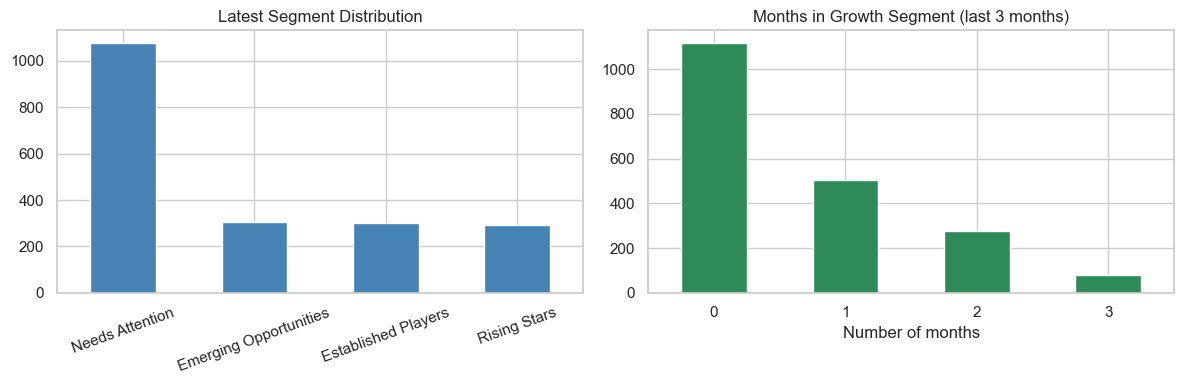

In [103]:
latest_month   = agg['year_month'].max()
lookback_start = latest_month - pd.DateOffset(months=LOOKBACK_MONTHS - 1)

trailing = agg[agg['year_month'] >= lookback_start].copy()
trailing['is_growth_segment'] = trailing['segment'].isin(GROWTH_SEGMENTS).astype(int)

stability = (
    trailing.groupby('name')
    .agg(
        growth_months   =('is_growth_segment', 'sum'),
        months_observed =('year_month',        'nunique'),
        latest_segment  =('segment',           'last'),
    )
    .reset_index()
)

stability['is_stable_growth'] = stability['growth_months'] >= MIN_GROWTH_MONTHS

print(f'Restaurants with stable growth : {stability["is_stable_growth"].sum():,}')
print(f'Latest segment distribution:')
print(stability['latest_segment'].value_counts())

# Visualise stability
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stability['latest_segment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Latest Segment Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

stability['growth_months'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title(f'Months in Growth Segment (last {LOOKBACK_MONTHS} months)')
axes[1].set_xlabel('Number of months')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### view remaining restaurants

In [104]:
latest = (
    agg.sort_values('year_month')
    .groupby('name')
    .tail(1)
    .copy()
)

latest = latest.merge(
    stability[['name', 'growth_months', 'months_observed', 'is_stable_growth', 'latest_segment']],
    on='name',
    how='left'
)

print(f'Latest snapshot: {len(latest):,} restaurants')
latest.head(5)


Latest snapshot: 2,808 restaurants


,restaurant_id,name,year_month,monthly_bookings,monthly_gmv,avg_gmv_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,log_gmv_prev,delta_growth_book,delta_growth_rev,delta_size_book,delta_size_rev,segment,growth_months,months_observed,is_stable_growth,latest_segment
0,1245,Earw Thai Suki Boran Mega Bangna,2025-01-01,2,3196.0,1598.0,2.0,2,True,0.0,...,0.0,0.0,0.0,1.098612,8.069968,Needs Attention,NaN,NaN,NaN,NaN
1,5268,Fak Marum Pathum Thani,2025-01-01,1,690.0,690.0,3.0,1,True,0.0,...,0.0,0.0,0.0,0.693147,6.538140,Needs Attention,NaN,NaN,NaN,NaN
2,4415,Sakae The PARQ,2025-01-01,1,9528.0,9528.0,6.0,1,True,0.0,...,0.0,0.0,0.0,0.693147,9.162095,Needs Attention,NaN,NaN,NaN,NaN
3,5029,HUI Suki Ratchaphruek,2025-01-01,1,518.0,518.0,2.0,1,True,0.0,...,0.0,0.0,0.0,0.693147,6.251904,Needs Attention,NaN,NaN,NaN,NaN
4,4042,Hey!Beanstro,2025-01-01,4,8530.0,2132.5,4.0,3,True,0.0,...,0.0,0.0,0.0,1.609438,9.051462,Needs Attention,NaN,NaN,NaN,NaN


# calculate demand related scores
- growth component
- booking demand
- ga4 demand

#### growth component

```
growth_component = score_growth_norm × 0.60 + delta_growth_norm × 0.40
```


In [105]:
delta_col = 'delta_growth_book' if 'delta_growth_book' in latest.columns else None

if delta_col:
    latest['delta_growth_norm'] = min_max_norm(latest[delta_col].fillna(0))
else:
    print('WARNING: delta_growth_book not found — acceleration signal set to 0.')
    latest['delta_growth_norm'] = 0.0

latest['score_growth_norm'] = min_max_norm(latest['score_growth'].fillna(0))

print('Growth subscores computed:')
latest.head(2)

Growth subscores computed:


,restaurant_id,name,year_month,monthly_bookings,monthly_gmv,avg_gmv_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,delta_growth_rev,delta_size_book,delta_size_rev,segment,growth_months,months_observed,is_stable_growth,latest_segment,delta_growth_norm,score_growth_norm
0,1245,Earw Thai Suki Boran Mega Bangna,2025-01-01,2,3196.0,1598.0,2.0,2,True,0.0,...,0.0,1.098612,8.069968,Needs Attention,NaN,NaN,NaN,NaN,0.315612,0.282082
1,5268,Fak Marum Pathum Thani,2025-01-01,1,690.0,690.0,3.0,1,True,0.0,...,0.0,0.693147,6.538140,Needs Attention,NaN,NaN,NaN,NaN,0.315612,0.282082


#### booking demand

```
booking_demand = booking_volume_norm      × 0.40
               + revenue_per_booking_norm × 0.30
               + booking_consistency_norm × 0.30
```

- **booking_volume_norm** — average monthly bookings (latest snapshot)
- **revenue_per_booking_norm** — monthly_revenue / monthly_bookings (revenue efficiency)
- **booking_consistency_norm** — 1 − coefficient of variation of monthly bookings over full history
  (higher = more stable demand)

In [106]:
# ── booking_consistency from full history ─────────────────────────────────────
# Coefficient of variation per restaurant → invert so stable = high score
booking_cv = (
    agg.groupby('name')['monthly_bookings']
    .agg(lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan)
    .rename('booking_cv')
    .reset_index()
)
booking_cv['booking_cv'] = booking_cv['booking_cv'].clip(0, 2).fillna(1)  # penalise missing as moderate
booking_cv['booking_consistency_raw'] = 1 - (booking_cv['booking_cv'] / 2)  # scale to [0, 1]

# ── Merge consistency into latest snapshot ────────────────────────────────────
latest = latest.merge(booking_cv[['name', 'booking_consistency_raw']], on='name', how='left')

# ── Booking demand subscores ──────────────────────────────────────────────────
latest['booking_volume_norm'] = min_max_norm(latest['monthly_bookings'].fillna(0))

latest['revenue_per_booking_raw'] = safe_div(
    latest['monthly_gmv'].fillna(0),
    latest['monthly_bookings'].replace(0, np.nan)
).fillna(0)
latest['revenue_per_booking_norm'] = min_max_norm(latest['revenue_per_booking_raw'])

latest['booking_consistency_norm'] = min_max_norm(latest['booking_consistency_raw'].fillna(0))

print('Booking demand subscores computed:')
print(latest[['booking_volume_norm', 'revenue_per_booking_norm', 'booking_consistency_norm']]
      .describe().T[['mean', 'std', 'min', 'max']].round(3))

Booking demand subscores computed:
                           mean    std  min  max
booking_volume_norm       0.013  0.050  0.0  1.0
revenue_per_booking_norm  0.073  0.078  0.0  1.0
booking_consistency_norm  0.677  0.178  0.0  1.0


In [107]:
latest.head(2)

,restaurant_id,name,year_month,monthly_bookings,monthly_gmv,avg_gmv_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,months_observed,is_stable_growth,latest_segment,delta_growth_norm,score_growth_norm,booking_consistency_raw,booking_volume_norm,revenue_per_booking_raw,revenue_per_booking_norm,booking_consistency_norm
0,1245,Earw Thai Suki Boran Mega Bangna,2025-01-01,2,3196.0,1598.0,2.0,2,True,0.0,...,NaN,NaN,NaN,0.315612,0.282082,0.5,0.001502,1598.0,0.059675,0.424526
1,5268,Fak Marum Pathum Thani,2025-01-01,1,690.0,690.0,3.0,1,True,0.0,...,NaN,NaN,NaN,0.315612,0.282082,0.5,0.000000,690.0,0.025250,0.424526


#### ga4 demand subscore

```
ga4_demand = listing_pull_norm   × 0.50
           + funnel_depth_norm   × 0.50
```

- **listing_pull** — avg itemsViewed across months
- **funnel_depth** — how far users progress view → cart → purchase

- identify _risk 1 - thin ga4 demand data_: when a restaurant has fewer than `MIN_GA4_MONTHS` **consecutive** months

In [108]:
subscores = latest[['restaurant_id','name','year_month','delta_growth_norm','score_growth_norm','booking_volume_norm','revenue_per_booking_norm','booking_consistency_norm']]

subscores.head(2)

,restaurant_id,name,year_month,delta_growth_norm,score_growth_norm,booking_volume_norm,revenue_per_booking_norm,booking_consistency_norm
0,1245,Earw Thai Suki Boran Mega Bangna,2025-01-01,0.315612,0.282082,0.001502,0.059675,0.424526
1,5268,Fak Marum Pathum Thani,2025-01-01,0.315612,0.282082,0.000000,0.025250,0.424526


In [109]:
campaign_impact['yearMonth'] = pd.to_datetime(campaign_impact['yearMonth'])
campaign_impact['period']    = campaign_impact['yearMonth'].dt.to_period('M')

listing_pull_df = (
    campaign_impact
    .groupby('itemName')
    .agg(
        listing_pull_raw =('itemsViewed', 'mean'),
        months_cnt       =('yearMonth',   'nunique'),
        max_consecutive  =('period',      max_consecutive_months),
    )
    .reset_index()
    .rename(columns={'itemName': 'name'})
)

listing_pull_df['thin_ga4_data'] = listing_pull_df['max_consecutive'] < MIN_GA4_MONTHS

print(f'Restaurants with listing_pull data : {len(listing_pull_df):,}')
print(f'Restaurants w thin data (< {MIN_GA4_MONTHS} consecutive months) : {listing_pull_df["thin_ga4_data"].sum():,}')

/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_3023/2581797108.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_impact


Restaurants with listing_pull data : 10,909
Restaurants w thin data (< 3 consecutive months) : 2,425


In [110]:
funnel_df = (
    campaign_impact
    .groupby('itemName')
    .agg(
        total_views       =('itemsViewed',      'sum'),
        total_add_to_cart =('itemsAddedToCart', 'sum'),
        total_purchased   =('itemsPurchased',   'sum'),
    )
    .reset_index()
    .rename(columns={'itemName': 'name'})
)

funnel_df['view_to_cart_rate']     = safe_div(funnel_df['total_add_to_cart'], funnel_df['total_views'])
funnel_df['cart_to_purchase_rate'] = safe_div(funnel_df['total_purchased'],   funnel_df['total_add_to_cart'])

funnel_df['funnel_depth_raw'] = (
    funnel_df['view_to_cart_rate']     * W_VIEW_TO_CART +
    funnel_df['cart_to_purchase_rate'] * W_CART_TO_PURCHASE
)

print(f'Restaurants with funnel data : {len(funnel_df):,}')

Restaurants with funnel data : 10,909


/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_3023/2874449903.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_impact


In [111]:
subscores = (
    subscores
    .merge(listing_pull_df[['name', 'listing_pull_raw', 'months_cnt', 'thin_ga4_data']], on='name', how='left')
    .merge(funnel_df[['name', 'view_to_cart_rate', 'cart_to_purchase_rate', 'funnel_depth_raw']], on='name', how='left')
)

subscores['listing_pull_norm'] = min_max_norm(subscores['listing_pull_raw'].fillna(0))
subscores['funnel_depth_norm'] = min_max_norm(subscores['funnel_depth_raw'].fillna(0))

print('GA4 demand subscores computed:')
print(subscores[['listing_pull_norm', 'funnel_depth_norm']]
      .describe().T[['mean', 'std', 'min', 'max']].round(3))

GA4 demand subscores computed:
                    mean    std  min  max
listing_pull_norm  0.024  0.051  0.0  1.0
funnel_depth_norm  0.032  0.042  0.0  1.0


In [112]:
subscores.head(2)

,restaurant_id,name,year_month,delta_growth_norm,score_growth_norm,booking_volume_norm,revenue_per_booking_norm,booking_consistency_norm,listing_pull_raw,months_cnt,thin_ga4_data,view_to_cart_rate,cart_to_purchase_rate,funnel_depth_raw,listing_pull_norm,funnel_depth_norm
0,1245,Earw Thai Suki Boran Mega Bangna,2025-01-01,0.315612,0.282082,0.001502,0.059675,0.424526,353.6875,16.0,False,0.098074,0.245045,0.186257,0.020273,0.023877
1,5268,Fak Marum Pathum Thani,2025-01-01,0.315612,0.282082,0.000000,0.025250,0.424526,21.0000,6.0,False,0.039683,0.400000,0.255873,0.001204,0.032802


# calculate campaign responsiveness score 
- internal mkt campaign responsiveness
- ga campaign responsiveness

#### internal mkt campaign responsivness

```
internal_mkt_campaign_responsiveness = lift_norm × 0.60 + roi_norm × 0.40
```

Aggregated from the internal marketing activity file.  
Restaurants **without** campaign history get `NaN`

In [113]:
# Aggregate to restaurant level
rest_mkt = (
    mkt.groupby('restaurant_id')
    .agg(
        n_campaigns          =('activity_id',           'nunique'),
        avg_lift_per_day     =('lift_per_day',          'mean'),
        total_incremental_rev=('incremental_revenue_thb','sum'),
        avg_roi              =('roi',                   'mean'),
        n_positive_lift      =('lift', lambda x: (x > 0).sum()),
        n_negative_lift      =('lift', lambda x: (x < 0).sum()),
        channels_used        =('channel', lambda x: '+'.join(sorted(x.dropna().unique()))),
    )
    .reset_index()
)

# Best channel = channel with highest avg lift_per_day for this restaurant
best_ch = (
    mkt.groupby(['restaurant_id', 'channel'])['lift_per_day']
    .mean()
    .reset_index()
    .sort_values('lift_per_day', ascending=False)
    .drop_duplicates('restaurant_id')
    .rename(columns={'channel': 'best_channel', 'lift_per_day': 'best_channel_avg_lift'})
)

rest_mkt = rest_mkt.merge(
    best_ch[['restaurant_id', 'best_channel', 'best_channel_avg_lift']],
    on='restaurant_id', how='left'
)

print(f'Restaurants with marketing history: {len(rest_mkt):,}')
rest_mkt.head(3)

Restaurants with marketing history: 380


,restaurant_id,n_campaigns,avg_lift_per_day,total_incremental_rev,avg_roi,n_positive_lift,n_negative_lift,channels_used,best_channel,best_channel_avg_lift
0,33.0,1,-1.50,0.000000e+00,NaN,0,1,CRM,CRM,-1.50
1,220.0,2,0.40,2.050000e+02,NaN,1,1,KOL,KOL,0.40
2,222.0,4,3.25,1.043174e+06,NaN,4,0,CRM,CRM,3.25


#### ga campaign responsiveness

```ga_campaign_responsiveness = gmv per view```

- identify _risk 3 - thin ga4 campaign data_: when a restaurant has fewer than `MIN_GA4_MONTHS` **consecutive** months


In [114]:
gmv_view['year_month'] = pd.to_datetime(gmv_view['year_month'])

ga_resp_df = (
    gmv_view
    .groupby('restaurant_id')
    .agg(
        avg_gmv_per_view =('gmv_per_view', 'mean'),
        n_months_gmv         =('year_month',   'nunique'),
    )
    .reset_index()
)

ga_resp_df['thin_gmv_data']              = ga_resp_df['n_months_gmv'] < MIN_GA4_MONTHS
ga_resp_df['ga_campaign_responsiveness'] = (
    ga_resp_df['avg_gmv_per_view']
    .fillna(0)
    .rank(pct=True)
)


print(f'Restaurants scored : {len(ga_resp_df):,}')
print(f'Restaurants which thin gmv data (< {MIN_GA4_MONTHS} months) : {ga_resp_df["thin_gmv_data"].sum():,}')

ga_resp_df['restaurant_id'] = pd.to_numeric(
    ga_resp_df['restaurant_id'], errors='coerce'
)
ga_resp_df.head(2)

Restaurants scored : 2,796
Restaurants which thin gmv data (< 3 months) : 736


,restaurant_id,avg_gmv_per_view,n_months_gmv,thin_gmv_data,ga_campaign_responsiveness
0,33,99.658336,13,False,0.964950
1,168,13.075872,10,False,0.329041


In [115]:
# check overlaps
combined_mkt = (
    rest_mkt.copy()
    .merge(ga_resp_df.copy(), on="restaurant_id")
    .fillna(0)
)
left_merge = rest_mkt.merge(ga_resp_df, on='restaurant_id', how='left')
print(f'inner join result : {combined_mkt["restaurant_id"].nunique():,}')
print(f'left  join result : {left_merge["restaurant_id"].nunique():,}')
print(f'dropped by inner  : {left_merge["restaurant_id"].nunique() - combined_mkt["restaurant_id"].nunique():,}')

mkt_ids  = set(rest_mkt['restaurant_id'].dropna().astype(int))
ga_ids   = set(ga_resp_df['restaurant_id'].dropna().astype(int))
print(f'\nrest_mkt IDs      : {len(mkt_ids):,}')
print(f'ga_resp_df IDs    : {len(ga_ids):,}')
print(f'overlap           : {len(mkt_ids & ga_ids):,}')
print(f'mkt only (no GA)  : {len(mkt_ids - ga_ids):,}')
print(f'GA only (no mkt)  : {len(ga_ids - mkt_ids):,}')

inner join result : 380
left  join result : 380
dropped by inner  : 0

rest_mkt IDs      : 380
ga_resp_df IDs    : 2,796
overlap           : 380
mkt only (no GA)  : 0
GA only (no mkt)  : 2,416


## join df with restaurant's sub score

Left join the 251 stable-growth restaurants with marketing performance data.
- Restaurants **with** marketing history get lift and ROI columns populated.
- Restaurants **without** marketing history get NaN for those columns — they are NOT excluded.

In [116]:
n_before = len(subscores)
latest_cols = [
    'restaurant_id',
    'is_seasonal',
    'booking_growth_rolling',
    'booking_growth_mom_rolling',
    'booking_growth_yoy_rolling',
    'score_growth_mom', 'score_growth_yoy','segment'
]

if 'restaurant_id' not in subscores.columns:
    combined = subscores.copy()
    combined['has_marketing'] = False
else:
    combined = subscores.merge(rest_mkt, on='restaurant_id', how='left')
    combined['has_marketing'] = combined['n_campaigns'].notna()

# Ensure marketing columns exist even if no rows matched the join
for col, default in {
    'avg_lift_per_day': np.nan, 'total_incremental_rev': np.nan,
    'avg_roi': np.nan, 'n_positive_lift': 0, 'n_negative_lift': 0,
    'channels_used': np.nan, 'best_channel': np.nan,
    'best_channel_avg_lift': np.nan, 'n_campaigns': np.nan,
}.items():
    if col not in combined.columns:
        combined[col] = default

# ── Merge GA campaign responsiveness ──────────────────────────────────────────
combined = combined.merge(
    ga_resp_df[['restaurant_id', 'avg_gmv_per_view', 'n_months_gmv', 'thin_gmv_data', 'ga_campaign_responsiveness']],
    on='restaurant_id', how='left'
)

# ── Guard: left joins must never drop rows ─────────────────────────────────────
assert len(combined) == n_before, (
    f'Row count changed after join: {n_before} → {len(combined)}. '
    'Check for duplicate keys in rest_mkt or ga_resp_df.'
)

# ── Internal marketing subscores ───────────────────────────────────────────────
combined['lift_norm'] = min_max_norm(combined['avg_lift_per_day'].fillna(0).clip(lower=0))
combined['roi_norm']  = min_max_norm(combined['avg_roi'].fillna(0).clip(lower=0))

combined = combined.merge(
    latest[latest_cols],
    on='restaurant_id',
    how='left'
)
print(f'combined: {combined.shape}')
print(f'  With marketing history      : {combined["has_marketing"].sum():,}')
print(f'  Without marketing history   : {(~combined["has_marketing"]).sum():,}')
print(f'  With GA responsiveness data : {combined["ga_campaign_responsiveness"].notna().sum():,}')

combined: (2808, 39)
  With marketing history      : 380
  Without marketing history   : 2,428
  With GA responsiveness data : 2,796


In [117]:
latest.columns

Index(['restaurant_id', 'name', 'year_month', 'monthly_bookings',
       'monthly_gmv', 'avg_gmv_per_booking', 'avg_guests', 'active_days',
       'in_analysis_window', 'booking_growth_mom', 'gmv_growth_mom',
       'bookings_prior_year', 'gmv_prior_year', 'booking_growth_yoy',
       'gmv_growth_yoy', 'months_of_history', 'has_full_year',
       'booking_growth_mom_rolling', 'gmv_growth_mom_rolling',
       'booking_growth_yoy_rolling', 'gmv_growth_yoy_rolling',
       'growth_signal_used', 'booking_growth_rolling', 'gmv_growth_rolling',
       'log_bookings', 'log_gmv', 'score_perf', 'growth_rate_blended',
       'score_growth', 'score_growth_mom', 'score_growth_yoy', 'is_seasonal',
       'booking_growth_rolling_prev', 'gmv_growth_rolling_prev',
       'log_bookings_prev', 'log_gmv_prev', 'delta_growth_book',
       'delta_growth_rev', 'delta_size_book', 'delta_size_rev', 'segment',
       'growth_months', 'months_observed', 'is_stable_growth',
       'latest_segment', 'delta_growth

In [118]:
subscores.columns

Index(['restaurant_id', 'name', 'year_month', 'delta_growth_norm',
       'score_growth_norm', 'booking_volume_norm', 'revenue_per_booking_norm',
       'booking_consistency_norm', 'listing_pull_raw', 'months_cnt',
       'thin_ga4_data', 'view_to_cart_rate', 'cart_to_purchase_rate',
       'funnel_depth_raw', 'listing_pull_norm', 'funnel_depth_norm'],
      dtype='object')

In [119]:
combined.columns

Index(['restaurant_id', 'name', 'year_month', 'delta_growth_norm',
       'score_growth_norm', 'booking_volume_norm', 'revenue_per_booking_norm',
       'booking_consistency_norm', 'listing_pull_raw', 'months_cnt',
       'thin_ga4_data', 'view_to_cart_rate', 'cart_to_purchase_rate',
       'funnel_depth_raw', 'listing_pull_norm', 'funnel_depth_norm',
       'n_campaigns', 'avg_lift_per_day', 'total_incremental_rev', 'avg_roi',
       'n_positive_lift', 'n_negative_lift', 'channels_used', 'best_channel',
       'best_channel_avg_lift', 'has_marketing', 'avg_gmv_per_view',
       'n_months_gmv', 'thin_gmv_data', 'ga_campaign_responsiveness',
       'lift_norm', 'roi_norm', 'is_seasonal', 'booking_growth_rolling',
       'booking_growth_mom_rolling', 'booking_growth_yoy_rolling',
       'score_growth_mom', 'score_growth_yoy', 'segment'],
      dtype='object')

In [120]:
# Sanity check — confirm join result
print('Combined shape:', combined.shape)
print('Columns:', combined.columns.tolist())
print()

# Diagnose if restaurant_id overlap is low
if 'restaurant_id' in combined.columns:
    momentum_ids  = set(latest['restaurant_id'].dropna().astype(int))
    marketing_ids = set(mkt['restaurant_id'].dropna().astype(int))
    print(f'Momentum restaurant IDs  : {len(momentum_ids):,}')
    print(f'Marketing restaurant IDs : {len(marketing_ids):,}')
    print(f'Overlap                  : {len(momentum_ids & marketing_ids):,}')

Combined shape: (2808, 39)
Columns: ['restaurant_id', 'name', 'year_month', 'delta_growth_norm', 'score_growth_norm', 'booking_volume_norm', 'revenue_per_booking_norm', 'booking_consistency_norm', 'listing_pull_raw', 'months_cnt', 'thin_ga4_data', 'view_to_cart_rate', 'cart_to_purchase_rate', 'funnel_depth_raw', 'listing_pull_norm', 'funnel_depth_norm', 'n_campaigns', 'avg_lift_per_day', 'total_incremental_rev', 'avg_roi', 'n_positive_lift', 'n_negative_lift', 'channels_used', 'best_channel', 'best_channel_avg_lift', 'has_marketing', 'avg_gmv_per_view', 'n_months_gmv', 'thin_gmv_data', 'ga_campaign_responsiveness', 'lift_norm', 'roi_norm', 'is_seasonal', 'booking_growth_rolling', 'booking_growth_mom_rolling', 'booking_growth_yoy_rolling', 'score_growth_mom', 'score_growth_yoy', 'segment']

Momentum restaurant IDs  : 2,808
Marketing restaurant IDs : 380
Overlap                  : 380


In [121]:
combined.columns

Index(['restaurant_id', 'name', 'year_month', 'delta_growth_norm',
       'score_growth_norm', 'booking_volume_norm', 'revenue_per_booking_norm',
       'booking_consistency_norm', 'listing_pull_raw', 'months_cnt',
       'thin_ga4_data', 'view_to_cart_rate', 'cart_to_purchase_rate',
       'funnel_depth_raw', 'listing_pull_norm', 'funnel_depth_norm',
       'n_campaigns', 'avg_lift_per_day', 'total_incremental_rev', 'avg_roi',
       'n_positive_lift', 'n_negative_lift', 'channels_used', 'best_channel',
       'best_channel_avg_lift', 'has_marketing', 'avg_gmv_per_view',
       'n_months_gmv', 'thin_gmv_data', 'ga_campaign_responsiveness',
       'lift_norm', 'roi_norm', 'is_seasonal', 'booking_growth_rolling',
       'booking_growth_mom_rolling', 'booking_growth_yoy_rolling',
       'score_growth_mom', 'score_growth_yoy', 'segment'],
      dtype='object')

## final composite priority score

Only the **251 stable-growth restaurants** are scored and ranked.

```
With marketing history:
    priority_score = growth_component (60%) + marketing_component (40%)
    growth_component    = score_growth (60%) + delta_growth (40%)
    marketing_component = avg_lift_per_day (60%) + avg_roi (40%)

Without marketing history:
    priority_score = growth_component only (renormalised to 0–100)
```

Both groups are ranked together in the final list — the tier label clarifies the basis of the score.

In [122]:
priority_df = combined.copy()

# raw subscores
priority_df['growth_component'] = (
    priority_df['score_growth_norm'] * W_SCORE_GROWTH +
    priority_df['delta_growth_norm'] * W_DELTA_GROWTH
)
priority_df['booking_demand'] = (
    priority_df['booking_volume_norm']      * W_BOOKING_VOLUME      +
    priority_df['revenue_per_booking_norm'] * W_REVENUE_PER_BOOKING +
    priority_df['booking_consistency_norm'] * W_BOOKING_CONSISTENCY
)

# ga4_demand and ga_campaign_responsiveness are adjusted by risk before
# being consumed — work on copies so original signal columns are preserved
ga4_demand_adj          = (
    priority_df['listing_pull_norm'] * W_LISTING_PULL +
    priority_df['funnel_depth_norm'] * W_FUNNEL_DEPTH
)
ga_campaign_resp_adj    = priority_df['ga_campaign_responsiveness'].fillna(0).copy()

#### risk assessment; change weightage of components

In [123]:
# Risk 1: thin GA demand data (from campaign_impact)
# missing from ga4 data entirely also counts as thin
priority_df['risk_thin_ga_demand_data'] = priority_df['thin_ga4_data'].fillna(True)
# Risk 2: inverse relationship between booking & GA demand data
# internal campaigns show positive lift but GA shows below-median commercial responsiveness
ga_demand_median = ga4_demand_adj.median()
priority_df['risk_inverse_attribution_rs'] = (
    (priority_df['booking_demand'].fillna(0) > priority_df['booking_demand'].median()) &
    (ga4_demand_adj.fillna(0) < ga_demand_median)
)

# Risk 3: thin GMV campaign data (from gmv_view)
# restaurant appears in too few months, avg_gmv_per_view unreliable
priority_df['risk_thin_gmv_data'] = priority_df['thin_gmv_data'].fillna(True)

# Risk 4: low GMV per view
# each view generates almost no revenue, GA responsiveness signal is weak
priority_df['risk_low_gmv_per_view'] = priority_df['avg_gmv_per_view'].fillna(0) < GMV_PER_VIEW_MIN
priority_df.drop(columns=['thin_ga4_data','thin_gmv_data'])

print('Risk flag counts across all restaurants:')
risk_cols = ['risk_thin_ga_demand_data', 'risk_inverse_attribution_rs', 'risk_thin_gmv_data', 'risk_low_gmv_per_view']
print(priority_df[risk_cols].sum().to_frame('n_flagged'))



Risk flag counts across all restaurants:
                             n_flagged
risk_thin_ga_demand_data           313
risk_inverse_attribution_rs        662
risk_thin_gmv_data                 748
risk_low_gmv_per_view               31


/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_3023/4251601240.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  priority_df['risk_thin_ga_demand_data'] = priority_df['thin_ga4_data'].fillna(True)
/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_3023/4251601240.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  priority_df['risk_thin_gmv_data'] = priority_df['thin_gmv_data'].fillna(True)


In [124]:
# apply risks to subscores
# Risk 1: < 3 consecutive months of GA demand data → ga4_demand × 0.80
ga4_demand_adj = ga4_demand_adj.where(
    ~priority_df['risk_thin_ga_demand_data'], ga4_demand_adj * 0.80
)

# Risk 2: inverse booking vs GA relationship → ga4_demand × 0.90
ga4_demand_adj = ga4_demand_adj.where(
    ~priority_df['risk_inverse_attribution_rs'], ga4_demand_adj * 0.90
)

# Risk 3: < 3 consecutive months of GA campaign data → ga_campaign_responsiveness × 0.80
ga_campaign_resp_adj = ga_campaign_resp_adj.where(
    ~priority_df['risk_thin_gmv_data'], ga_campaign_resp_adj * 0.80
)

# Risk 4: avg gmv/view < 1 → ga_campaign_responsiveness × 0.90
ga_campaign_resp_adj = ga_campaign_resp_adj.where(
    ~priority_df['risk_low_gmv_per_view'], ga_campaign_resp_adj * 0.90
)

# Store adjusted subscores for auditability
priority_df['ga4_demand']               = ga4_demand_adj
priority_df['ga_campaign_resp_adj']     = ga_campaign_resp_adj

# level-1 campaign responsiveness using adjusted subscores
priority_df['internal_mkt_campaign_responsiveness'] = (
    priority_df['lift_norm'] * W_LIFT +
    priority_df['roi_norm']  * W_ROI
)

has_mkt = priority_df['has_marketing']

priority_df['campaign_responsiveness'] = np.where(
    has_mkt,
    priority_df['internal_mkt_campaign_responsiveness'] * W_INTERNAL_MKT_RESP +
    ga_campaign_resp_adj * W_GA_CAMPAIGN_RESP,
    ga_campaign_resp_adj   # GA signal only; already normalised [0,1]
)

# level 2 fixed weights split by marketing history 
priority_df['w_growth']   = np.where(has_mkt, W_GROWTH_MKT,  W_GROWTH_NO_MKT)
priority_df['w_booking']  = np.where(has_mkt, W_BOOKING_MKT, W_BOOKING_NO_MKT)
priority_df['w_ga4']      = np.where(has_mkt, W_GA4_MKT,     W_GA4_NO_MKT)
priority_df['w_campaign'] = np.where(has_mkt, W_MKT_MKT,     W_MKT_NO_MKT)

#  check if weights must already sum to 1 by construction
assert (priority_df[['w_growth', 'w_booking', 'w_ga4', 'w_campaign']].sum(axis=1).round(6) == 1).all(), \
    'Weights do not sum to 1 — check W_ constants in config'

# level-2 priority_score 
## filter off no ga records and mkt history priority score calculation
no_ga4_mask = priority_df['ga4_demand'].isna() | (priority_df['ga4_demand'] == 0)
no_campaign_mask = priority_df['campaign_responsiveness'].isna() | (priority_df['campaign_responsiveness'] == 0)
filteredoff = no_ga4_mask & no_campaign_mask

priority_df.loc[~filteredoff, 'priority_score'] = (
    priority_df['growth_component']       * priority_df['w_growth']   +
    priority_df['booking_demand']          * priority_df['w_booking']  +
    priority_df['ga4_demand']              * priority_df['w_ga4']      +
    priority_df['campaign_responsiveness'] * priority_df['w_campaign']
)

priority_df.loc[filteredoff, 'priority_score'] = (
    priority_df['growth_component'] * 0.50 +
    priority_df['booking_demand']   * 0.50
)

priority_df['priority_score'] = min_max_norm(priority_df['priority_score']) * 100


print('Risk flag counts:')
risk_cols = ['risk_thin_ga_demand_data', 'risk_inverse_attribution_rs',
             'risk_thin_gmv_data', 'risk_low_gmv_per_view']
print(priority_df[risk_cols].sum().to_frame('n_flagged'))

print('\nLevel-1 score summary:')
l1_cols = ['growth_component', 'booking_demand', 'ga4_demand',
           'internal_mkt_campaign_responsiveness', 'campaign_responsiveness']
print(priority_df[l1_cols].describe().T[['mean', 'std', 'min', 'max']].round(3))

print('\nLevel-2 priority_score:')
print(priority_df['priority_score'].describe().T[['mean', 'std', 'min', 'max']].round(3))

Risk flag counts:
                             n_flagged
risk_thin_ga_demand_data           313
risk_inverse_attribution_rs        662
risk_thin_gmv_data                 748
risk_low_gmv_per_view               31

Level-1 score summary:
                                       mean    std    min    max
growth_component                      0.354  0.115  0.050  0.949
booking_demand                        0.230  0.062  0.032  0.709
ga4_demand                            0.028  0.032  0.000  0.511
internal_mkt_campaign_responsiveness  0.005  0.028  0.000  0.600
campaign_responsiveness               0.428  0.267  0.000  0.999

Level-2 priority_score:
mean     37.030
std      12.642
min       0.000
max     100.000
Name: priority_score, dtype: float64


In [125]:
print(priority_df[priority_df["risk_thin_ga_demand_data"] == True]["name"])


23                              MJ Hotpot 
24                  Madoka Sumibi Izakaya 
52                  MeeYumCharoen Sathorn 
72                         Traveler's Tap 
79      Summer Kiss Restaurant & Moon Bar 
                       ...                
2751                Koko Japanese Omakase 
2752     Thong Dang Southern Thai Cuisine 
2763        Korea House Gold - The Fourth 
2779                Tikishi Paradise Park 
2794                         Khao Ekkamai 
Name: name, Length: 313, dtype: object


In [126]:
priority_df.head(4)

,restaurant_id,name,year_month,delta_growth_norm,score_growth_norm,booking_volume_norm,revenue_per_booking_norm,booking_consistency_norm,listing_pull_raw,months_cnt,...,risk_low_gmv_per_view,ga4_demand,ga_campaign_resp_adj,internal_mkt_campaign_responsiveness,campaign_responsiveness,w_growth,w_booking,w_ga4,w_campaign,priority_score
0,1245,Earw Thai Suki Boran Mega Bangna,2025-01-01,0.315612,0.282082,0.001502,0.059675,0.424526,353.687500,16.0,...,False,0.022075,0.569671,0.0,0.569671,0.4,0.4,0.15,0.05,26.221721
1,5268,Fak Marum Pathum Thani,2025-01-01,0.315612,0.282082,0.000000,0.025250,0.424526,21.000000,6.0,...,False,0.017003,0.547639,0.0,0.547639,0.4,0.4,0.15,0.05,24.823835
2,4415,Sakae The PARQ,2025-01-01,0.315612,0.282082,0.000000,0.360328,0.424526,278.307692,13.0,...,False,0.019030,0.780830,0.0,0.780830,0.4,0.4,0.15,0.05,36.523423
3,5029,HUI Suki Ratchaphruek,2025-01-01,0.315612,0.282082,0.000000,0.018729,0.424526,55.500000,14.0,...,False,0.011997,0.234049,0.0,0.234049,0.4,0.4,0.15,0.05,20.963905


## Assign Priority Tier & Recommended Channel

Two simple tiers within the stable-growth restaurants:
- 🔴 **Activate — proven marketing response**: has marketing history and positive lift
- 🟠 **Activate — untapped, no prior spend**: no marketing history, growing organically

In [127]:
priority_df['priority_tier'] = np.where(
    priority_df['has_marketing'] & (priority_df['avg_lift_per_day'].fillna(0) > 0),
    '🔴 Activate — proven marketing response',
    np.where(
        ~priority_df['has_marketing'],
        '🟠 Activate — untapped, no prior spend',
        '🟡 Activate — review channel strategy'
    )
)

priority_df['recommended_channel'] = priority_df.apply(recommend_channel, axis=1)

print('Priority tier distribution:')
print(priority_df['priority_tier'].value_counts())

Priority tier distribution:
priority_tier
🟠 Activate — untapped, no prior spend     2428
🔴 Activate — proven marketing response     263
🟡 Activate — review channel strategy       117
Name: count, dtype: int64


## Final Ranked Output

Ranked list of the ~251 stable-growth restaurants, sorted by priority score descending.

In [128]:
output_cols = [
    # Identity
    'name', 'restaurant_id',
    'segment', 'growth_months', 'months_observed', 'is_stable_growth', 'has_marketing',
    # Tier & final score
    'priority_score', 'priority_tier', 'recommended_channel',
    # Level-1 scores
    'growth_component', 'booking_demand', 'ga4_demand',
    'internal_mkt_campaign_responsiveness', 'campaign_responsiveness',
    # Subscores — growth
    'score_growth', 'score_growth_norm', 'delta_growth_norm',
    # Subscores — booking
    'monthly_bookings', 'monthly_gmv',
    'booking_volume_norm', 'revenue_per_booking_norm', 'booking_consistency_norm',
    # Subscores — GA4 demand
    'listing_pull_raw', 'months_cnt', 'listing_pull_norm',
    'view_to_cart_rate', 'cart_to_purchase_rate', 'funnel_depth_raw', 'funnel_depth_norm',
    # Subscores — internal marketing
    'n_campaigns', 'avg_lift_per_day', 'avg_roi',
    'n_positive_lift', 'n_negative_lift', 'channels_used', 'best_channel',
    'lift_norm', 'roi_norm',
    # Subscores — GA campaign responsiveness
    'avg_gmv_per_view', 'n_months_gmv', 'ga_campaign_responsiveness',
    # Risk flags
    'risk_thin_ga_demand_data', 'risk_inverse_attribution_rs',
    'risk_thin_gmv_data', 'risk_low_gmv_per_view',
    # prev dataset
    "is_seasonal",
    "booking_growth_rolling",
    "booking_growth_mom_rolling",
    "booking_growth_yoy_rolling",
    'score_growth_mom', 'score_growth_yoy'

]

output_cols = [c for c in output_cols if c in priority_df.columns]

priority_list = (
    priority_df[output_cols]
    .sort_values('priority_score', ascending=False)
    .reset_index(drop=True)
)
priority_list.index += 1
priority_list.index.name = 'rank'

priority_list.to_csv(OUTPUT_PATH)

segment_cols = [c for c in ['restaurant_id', 'name', 'latest_segment', 'score_perf', 'score_growth', 'year_month']
                if c in latest.columns]
(
    latest[segment_cols]
    .sort_values('name')
    .drop_duplicates('name', keep='last')
    .reset_index(drop=True)
    .to_parquet(SEGMENT_OUTPUT_PATH, index=False)
)
print(f'Saved priority list  → {OUTPUT_PATH}  ({len(priority_list):,} restaurants)')
print(f'Saved segment labels → {SEGMENT_OUTPUT_PATH}')
priority_list.head(10)

Saved priority list  → ../_4_final_outputs/data_output/priority_list_ga4.csv  (2,808 restaurants)
Saved segment labels → ../_2_feature_engineering+momentum/data_output/priority_latest_momentum_labels.parquet


,name,restaurant_id,segment,has_marketing,priority_score,priority_tier,recommended_channel,growth_component,booking_demand,ga4_demand,...,risk_thin_ga_demand_data,risk_inverse_attribution_rs,risk_thin_gmv_data,risk_low_gmv_per_view,is_seasonal,booking_growth_rolling,booking_growth_mom_rolling,booking_growth_yoy_rolling,score_growth_mom,score_growth_yoy
rank,,,,,,,,,,,,,,,,,,,,,
1,NAMA Japanese and Seafood Buffet (Hungry Hub),5149,Rising Stars,True,100.000000,🔴 Activate — proven marketing response,CRM,0.654956,0.709263,0.269548,...,False,False,False,False,False,1.220302,0.088233,1.220302,0.271090,0.669889
2,Nan Yuan Chinese Restaurant Avani Ratchada Ban...,4232,Rising Stars,False,93.194020,"🟠 Activate — untapped, no prior spend",CRM,0.824547,0.306875,0.044744,...,False,False,False,False,False,1.659091,0.586806,1.659091,0.477603,0.870976
3,CHOB Craft Beef & Beer,5181,Emerging Opportunities,False,85.219978,"🟠 Activate — untapped, no prior spend",CRM,0.854506,0.245838,0.000000,...,True,True,False,False,False,2.000000,0.111111,2.000000,0.256998,0.888377
4,Boon Tong Kee Terminal 21 Rama 3,3561,Rising Stars,False,83.712680,"🟠 Activate — untapped, no prior spend",CRM,0.835320,0.237332,0.024623,...,False,False,False,False,False,2.000000,0.250000,2.000000,0.285492,0.845765
5,DID - Dine in the Dark at Sheraton Grande Sukh...,5837,Rising Stars,False,79.846538,"🟠 Activate — untapped, no prior spend",CRM,0.729587,0.271649,0.017750,...,False,True,False,False,False,1.138889,1.138889,NaN,0.693474,NaN
6,Great Harbour International Buffet,3005,Rising Stars,True,78.659623,🔴 Activate — proven marketing response,KOL,0.531734,0.501323,0.252476,...,False,False,False,False,True,0.805455,0.098506,0.805455,0.272446,0.499780
7,Vinifera Wine Bar & Restaurant,3195,Rising Stars,False,78.212025,"🟠 Activate — untapped, no prior spend",CRM,0.804167,0.197891,0.024190,...,False,False,False,False,False,1.750000,0.958333,1.750000,0.571661,0.785657
8,The Hungry Duck Central Embassy,4639,Rising Stars,False,77.820823,"🟠 Activate — untapped, no prior spend",CRM,0.780499,0.228934,0.029254,...,False,False,False,False,False,1.600000,0.616667,1.600000,0.468257,0.916522
9,The Emerald Coffee Shop | The Emerald Hotel,6017,Rising Stars,True,77.228280,🔴 Activate — proven marketing response,CRM,0.449616,0.457642,0.076969,...,False,False,False,False,False,0.642166,0.642166,NaN,0.460466,NaN


In [129]:
priority_list.columns

Index(['name', 'restaurant_id', 'segment', 'has_marketing', 'priority_score',
       'priority_tier', 'recommended_channel', 'growth_component',
       'booking_demand', 'ga4_demand', 'internal_mkt_campaign_responsiveness',
       'campaign_responsiveness', 'score_growth_norm', 'delta_growth_norm',
       'booking_volume_norm', 'revenue_per_booking_norm',
       'booking_consistency_norm', 'listing_pull_raw', 'months_cnt',
       'listing_pull_norm', 'view_to_cart_rate', 'cart_to_purchase_rate',
       'funnel_depth_raw', 'funnel_depth_norm', 'n_campaigns',
       'avg_lift_per_day', 'avg_roi', 'n_positive_lift', 'n_negative_lift',
       'channels_used', 'best_channel', 'lift_norm', 'roi_norm',
       'avg_gmv_per_view', 'n_months_gmv', 'ga_campaign_responsiveness',
       'risk_thin_ga_demand_data', 'risk_inverse_attribution_rs',
       'risk_thin_gmv_data', 'risk_low_gmv_per_view', 'is_seasonal',
       'booking_growth_rolling', 'booking_growth_mom_rolling',
       'booking_growth_y

## 11) Visualisations

=== PRIORITY TIER SUMMARY ===
                                        count  avg_score  avg_growth  avg_lift_day
priority_tier                                                                     
🔴 Activate — proven marketing response    263     38.965       0.429         1.699
🟠 Activate — untapped, no prior spend    2428     36.962       0.367           NaN
🟡 Activate — review channel strategy      117     34.094       0.420        -0.479


/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_3023/3793669069.py:27: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_3023/3793669069.py:27: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0b/xsxtfvf90kb1dz8710270xd40000gn/T/ipykernel_3023/3793669069.py:27: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/liyunling/Downloads/GitHub/OPE/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/liyunling/Downloads/GitHub/OPE/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/

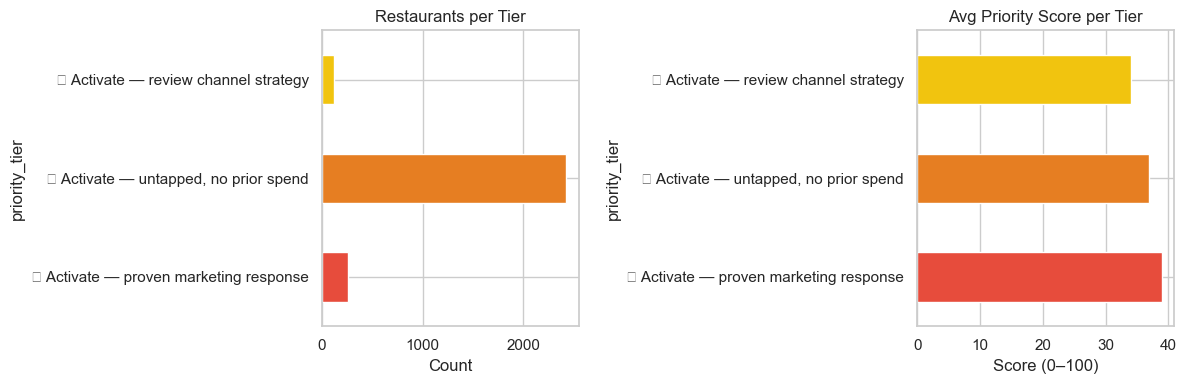

In [130]:
# ── Tier breakdown ────────────────────────────────────────────────────────────
tier_summary = (
    priority_list.groupby('priority_tier')
    .agg(
        count        =('priority_score',   'count'),
        avg_score    =('priority_score',   'mean'),
        avg_growth   =('score_growth_norm',     'mean'),
        avg_lift_day =('avg_lift_per_day', 'mean'),
    )
    .round(3)
    .sort_values('avg_score', ascending=False)
)

print('=== PRIORITY TIER SUMMARY ===')
print(tier_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tier_summary['count'].plot(kind='barh', ax=axes[0], color=['#e74c3c', '#e67e22', '#f1c40f'])
axes[0].set_title('Restaurants per Tier')
axes[0].set_xlabel('Count')

tier_summary['avg_score'].plot(kind='barh', ax=axes[1], color=['#e74c3c', '#e67e22', '#f1c40f'])
axes[1].set_title('Avg Priority Score per Tier')
axes[1].set_xlabel('Score (0–100)')

plt.tight_layout()
plt.show()

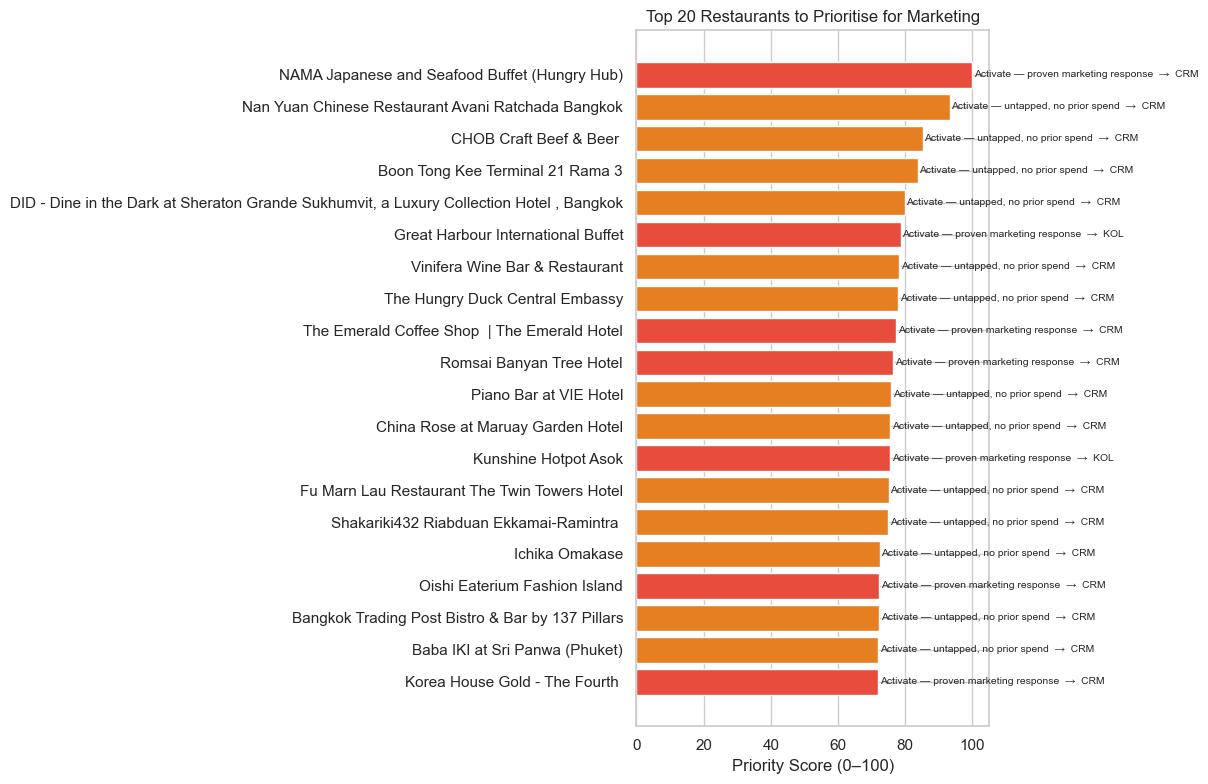

In [131]:
top20 = priority_list.head(20).copy()
tier_color_map = {
    '🔴 Activate — proven marketing response': '#e74c3c',
    '🟠 Activate — untapped, no prior spend':  '#e67e22',
    '🟡 Activate — review channel strategy':   '#f1c40f',
}
colors = top20['priority_tier'].map(tier_color_map).fillna('#95a5a6')

plt.figure(figsize=(12, 8))
bars = plt.barh(top20['name'], top20['priority_score'], color=colors)
plt.xlabel('Priority Score (0–100)')
plt.title('Top 20 Restaurants to Prioritise for Marketing')
plt.gca().invert_yaxis()
for bar, (_, row) in zip(bars, top20.iterrows()):
    label = f"{row['priority_tier']}  →  {row.get('recommended_channel', '')}"
    label = label.replace('🔴 ', '').replace('🟠 ', '').replace('🟡 ', '')
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             label, va='center', fontsize=7.5)
plt.tight_layout()
plt.show()

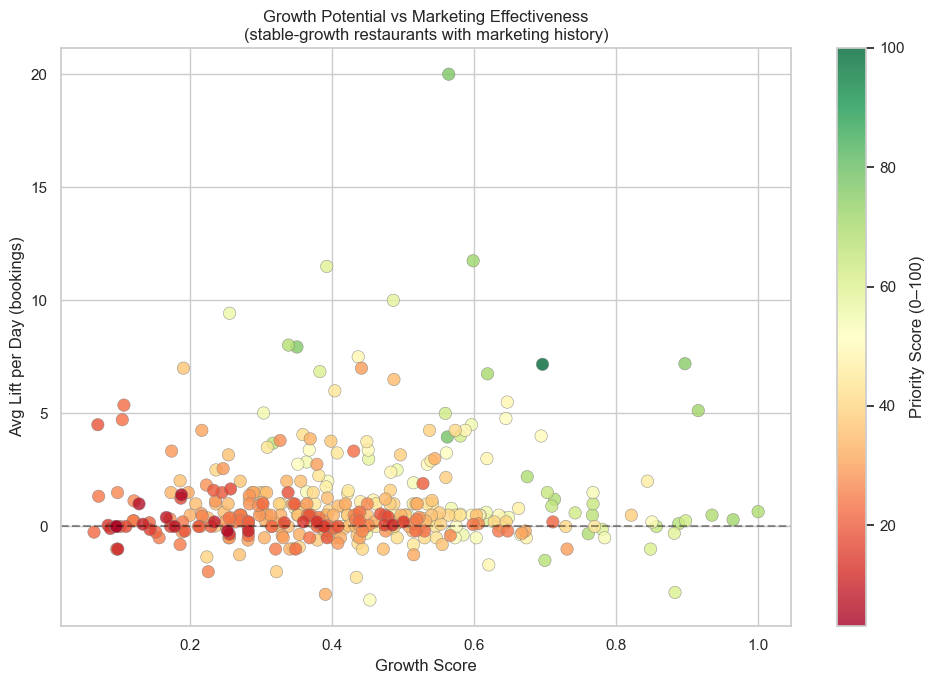

In [132]:
# ── Growth vs Marketing Lift scatter (stable-growth restaurants only) ─────────
plot_df = priority_list[priority_list['has_marketing']].copy()

if len(plot_df) == 0:
    print('No restaurants with marketing history in the priority list — skipping scatter.')
else:
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        plot_df['score_growth_norm'],
        plot_df['avg_lift_per_day'].fillna(0),
        c=plot_df['priority_score'],
        cmap='RdYlGn',
        s=80,
        alpha=0.8,
        edgecolors='grey',
        linewidths=0.4
    )
    plt.colorbar(scatter, label='Priority Score (0–100)')
    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.xlabel('Growth Score')
    plt.ylabel('Avg Lift per Day (bookings)')
    plt.title('Growth Potential vs Marketing Effectiveness\n(stable-growth restaurants with marketing history)')
    plt.tight_layout()
    plt.show()

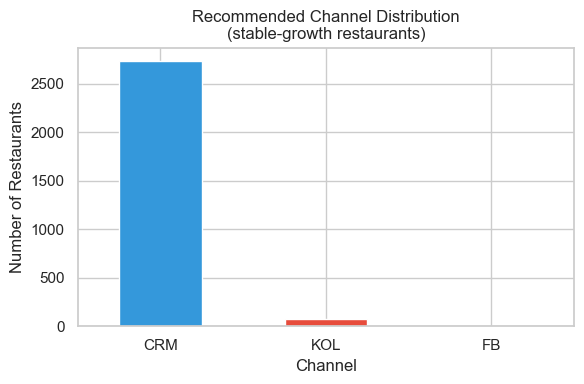

In [133]:
# ── Recommended channel distribution ─────────────────────────────────────────
ch_counts = priority_list['recommended_channel'].value_counts()

plt.figure(figsize=(6, 4))
ch_counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Recommended Channel Distribution\n(stable-growth restaurants)')
plt.xlabel('Channel')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12) Summary Table

Final actionable summary — one row per tier with key averages.

In [134]:
summary = (
    priority_list.groupby('priority_tier')
    .agg(
        n_restaurants       =('name',               'count'),
        avg_priority_score  =('priority_score',     'mean'),
        avg_growth          =('growth_component',   'mean'),
        avg_booking_demand  =('booking_demand',     'mean'),
        avg_ga4_demand      =('ga4_demand',         'mean'),
        avg_campaign_resp   =('campaign_responsiveness','mean'),
        avg_lift_per_day    =('avg_lift_per_day',   'mean'),
        avg_gmv_per_view    =('avg_gmv_per_view',   'mean'),
        top_channel         =('recommended_channel', lambda x: x.value_counts().index[0]),
    )
    .round(3)
    .sort_values('avg_priority_score', ascending=False)
)

print('=== FINAL SUMMARY ===')
summary

=== FINAL SUMMARY ===


,n_restaurants,avg_priority_score,avg_growth,avg_booking_demand,avg_ga4_demand,avg_campaign_resp,avg_lift_per_day,avg_gmv_per_view,top_channel
priority_tier,,,,,,,,,
🔴 Activate — proven marketing response,263,38.965,0.391,0.262,0.056,0.291,1.699,45.238,CRM
"🟠 Activate — untapped, no prior spend",2428,36.962,0.349,0.227,0.024,0.452,NaN,28.734,CRM
🟡 Activate — review channel strategy,117,34.094,0.383,0.241,0.045,0.237,-0.479,35.881,CRM
